<a href="https://colab.research.google.com/github/DaJeong03/voice-ai-study/blob/main/day03_spectrogram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 한글 폰트 설정
!apt-get install -y fonts-nanum
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.


In [2]:
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 오디오 불러오기
y, sr = librosa.load(librosa.ex('trumpet'))
print(f"샘플레이트: {sr}Hz, 길이: {len(y)/sr:.2f}초")

샘플레이트: 22050Hz, 길이: 5.33초


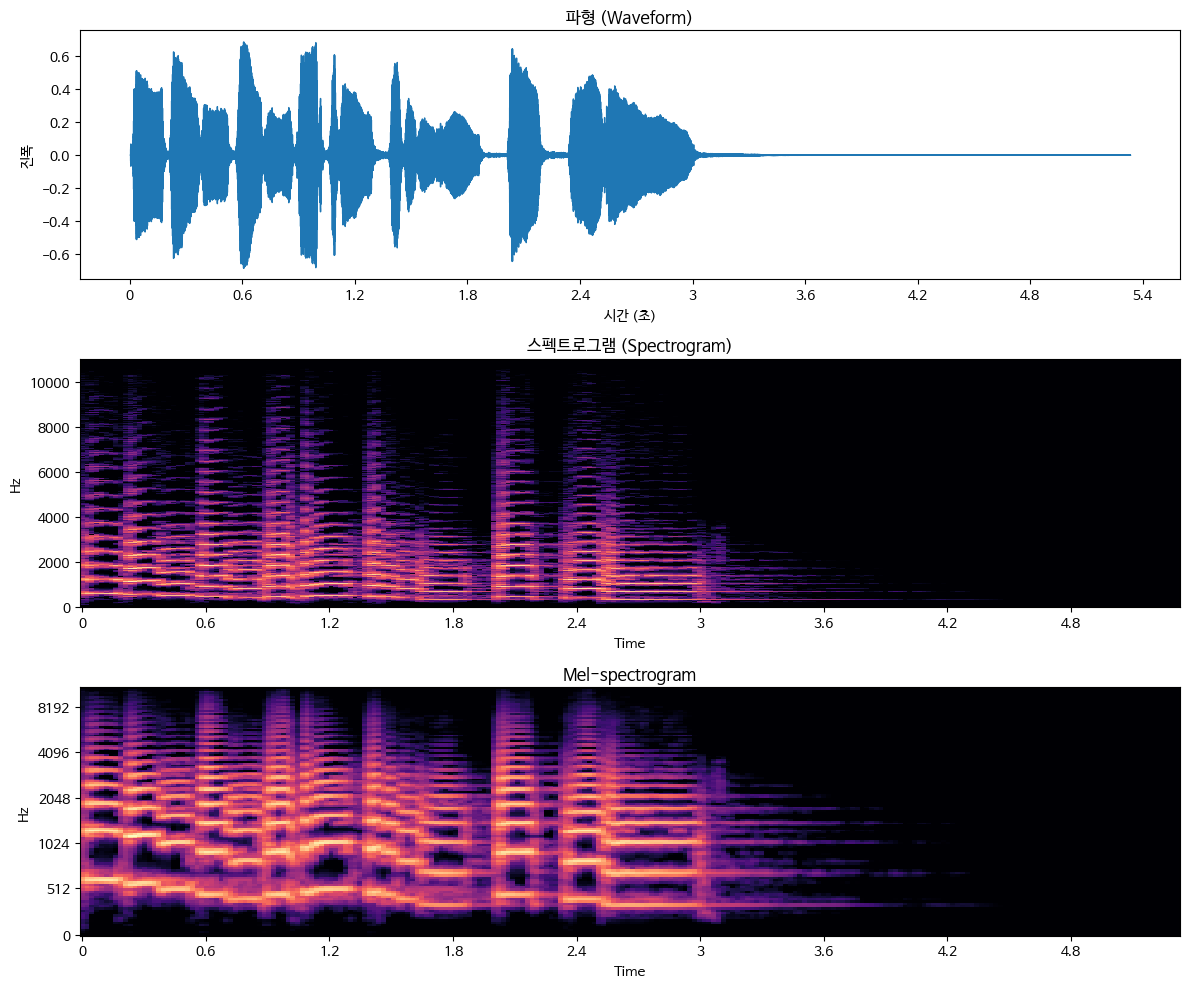

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# 1. 파형
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title("파형 (Waveform)")
axes[0].set_xlabel("시간 (초)")
axes[0].set_ylabel("진폭")

# 2. 스펙트로그램
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1])
axes[1].set_title("스펙트로그램 (Spectrogram)")

# 3. Mel-spectrogram
mel = librosa.feature.melspectrogram(y=y, sr=sr)
mel_db = librosa.power_to_db(mel, ref=np.max)
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[2])
axes[2].set_title("Mel-spectrogram")

plt.tight_layout()
plt.show()